<!-- CODEx Chinese cell explanation: start -->
### Cell 01 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 01 — Computational step 01

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [1]:

from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import StandardScaler

plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "grid.linestyle": "--",
})

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUT_DIR = PROJECT_ROOT / "outputs_step2"
FIG_DIR = OUT_DIR / "figures"
for p in [OUT_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATASET_PATH = DATA_DIR / "step1_simulation_dataset.csv"
TARGET = "eui_kwh_m2"   # Start with EUI.
RANDOM_SEED = 42
FAST_MODE = os.environ.get("EUI_FAST_MODE", "0") == "1"
BOOTSTRAP_N = 100 if FAST_MODE else 1000


<!-- CODEx Chinese cell explanation: start -->
### Cell 02 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 02 — Computational step 02

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [2]:
# ---------- 1) Load data ----------
assert DATASET_PATH.exists(), "Please run Step 1 first to generate step1_simulation_dataset.csv"
df = pd.read_csv(DATASET_PATH)
assert TARGET in df.columns, f"Target column missing from the dataset: {TARGET}"

# 1) Encode orientation as circular features.
df["orientation_sin"] = np.sin(np.deg2rad(df["orientation_deg"]))
df["orientation_cos"] = np.cos(np.deg2rad(df["orientation_deg"]))
df["footprint_area_m2"] = df["building_length"] * df["building_width"]
df["aspect_ratio"] = df["building_length"] / df["building_width"]

# 2) Convert window type into dummy variables.
df = pd.get_dummies(df, columns=["window_type_id"], prefix="window_type", drop_first=True)

# ---------- 1b) Geometry-based validation metrics ----------
df["building_height_calc_m"] = df["floor_num"] * df["floor_height"]

# Recover length and width from footprint area and aspect ratio.
L = np.sqrt(df["footprint_area_m2"] * df["aspect_ratio"])
W = np.sqrt(df["footprint_area_m2"] / df["aspect_ratio"])
P = 2 * (L + W)

# Envelope area divided by gross floor area (approximate).
df["envelope_to_floor_ratio"] = (
    P * df["building_height_calc_m"] + 2 * df["footprint_area_m2"]
) / df["gross_floor_area_m2"]

# 3) Final features used in this analysis step.
analysis_features = [
    'insul_thick', 'wwr', 'wall_thick',
    'u_win_n', 'u_win_s', 'u_win_e', 'u_win_w',
    'u_wall', 'u_roof', 'u_ground',
    'shgc_n', 'shgc_s', 'shgc_e', 'shgc_w',
    'roof_insul_thick',

    # Building geometry after reconstruction.
    'floor_num', 'footprint_area_m2', 'aspect_ratio', 'floor_height',
    'orientation_sin', 'orientation_cos',

    # Internal function and thermal-zone variables.
    'public_area', 'room_area', 'room_count',

    # Operation and system variables.
    'equip_power', 'dhw_per_person', 'occupancy_density', 'light_power',
    'cool_set', 'heat_set', 'dhw_temp',
    'cop_cooling', 'cop_heating', 'boiler_eff', 'fan_eff',
    'fresh_air_ach', 'operation_hours',

    # Window-type dummy variables.
    'window_type_2', 'window_type_3'
]

feature_groups = {
    "Envelope": [
        'insul_thick', 'wwr', 'wall_thick',
        'u_win_n', 'u_win_s', 'u_win_e', 'u_win_w',
        'u_wall', 'u_roof', 'u_ground',
        'shgc_n', 'shgc_s', 'shgc_e', 'shgc_w',
        'roof_insul_thick', 'window_type_2', 'window_type_3'
    ],
    "Geometry_Form": [
        'floor_num', 'footprint_area_m2', 'aspect_ratio', 'floor_height',
        'orientation_sin', 'orientation_cos'
    ],
    "Program_Zoning": [
        'public_area', 'room_area', 'room_count'
    ],
    "Operation_HVAC": [
        'equip_power', 'dhw_per_person', 'occupancy_density', 'light_power',
        'cool_set', 'heat_set', 'dhw_temp',
        'cop_cooling', 'cop_heating', 'boiler_eff', 'fan_eff',
        'fresh_air_ach', 'operation_hours'
    ]
}

feature_fullname_map = {
    "insul_thick": "External wall insulation layer thickness (m)",
    "wwr": "Overall window-to-wall ratio (-)",
    "wall_thick": "External wall structure thickness (m)",

    "u_win_n": "Heat transfer coefficient of north-facing windows (W/(m²·K))",
    "u_win_s": "Heat transfer coefficient of south-facing windows (W/(m²·K))",
    "u_win_e": "Heat transfer coefficient of east-facing windows (W/(m²·K))",
    "u_win_w": "Heat transfer coefficient of west-facing windows (W/(m²·K))",

    "u_wall": "Heat transfer coefficient of main external wall structure (W/(m²·K))",
    "u_roof": "Heat transfer coefficient of roof (W/(m²·K))",
    "u_ground": "Heat transfer coefficient of ground foundation (W/(m²·K))",

    "shgc_n": "Solar heat gain coefficient of north-facing windows (-)",
    "shgc_s": "Solar heat gain coefficient of south-facing windows (-)",
    "shgc_e": "Solar heat gain coefficient of east-facing windows (-)",
    "shgc_w": "Solar heat gain coefficient of west-facing windows (-)",

    "roof_insul_thick": "Roof insulation layer thickness (m)",

    "floor_num": "Total number of floors (floors)",
    "footprint_area_m2": "Building footprint area = main building length × main building width (m²)",
    "aspect_ratio": "Building length-to-width ratio (-)",
    "floor_height": "Standard floor height (m)",

    "orientation_sin": "Sine term of overall building orientation (-)",
    "orientation_cos": "Cosine term of overall building orientation (-)",

    "public_area": "Total area of public areas (m²)",
    "room_area": "Floor area of a single guest room (m²)",
    "room_count": "Total number of guest rooms (rooms)",

    "equip_power": "Indoor equipment power density (W/m²)",
    "dhw_per_person": "Daily domestic hot water consumption per capita (m³/(person·d))",
    "occupancy_density": "Personnel density (person/m²)",
    "light_power": "Indoor lighting power density (W/m²)",

    "cool_set": "Summer cooling set temperature (°C)",
    "heat_set": "Winter heating set temperature (°C)",
    "dhw_temp": "Domestic hot water supply temperature (°C)",

    "cop_cooling": "Rated COP of refrigeration unit (-)",
    "cop_heating": "COP of heat pump heating (-)",
    "boiler_eff": "Thermal efficiency of hot water boiler (-)",
    "fan_eff": "Efficiency of air conditioning fan (-)",
    "fresh_air_ach": "Fresh air exchange rate (times/h)",
    "operation_hours": "Total annual operating hours of system (h)",

    "window_type_2": "Window construction type dummy: Type 2 relative to Type 1 baseline (-)",
    "window_type_3": "Window construction type dummy: Type 3 relative to Type 1 baseline (-)",
}

X = df[analysis_features].copy()
y = df[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature count:", len(analysis_features))

X shape: (121, 39)
y shape: (121,)
Feature count: 39


<!-- CODEx Chinese cell explanation: start -->
### Cell 03 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 03 — Computational step 03

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [3]:
# ---------- 2) VIF check ----------
def compute_vif_table(X_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in X_df.columns:
        y_col = X_df[col].values
        X_other = X_df.drop(columns=[col]).values
        model = LinearRegression()
        model.fit(X_other, y_col)
        r2 = model.score(X_other, y_col)
        vif = np.inf if r2 >= 0.999999 else 1.0 / (1.0 - r2)
        rows.append({"feature": col, "VIF": vif})
    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

vif_df = compute_vif_table(X)
vif_df["feature_full"] = vif_df["feature"].map(feature_fullname_map)
vif_df = vif_df[["feature", "feature_full", "VIF"]]

vif_df.to_csv(OUT_DIR / "vif_table.csv", index=False, encoding="utf-8-sig")
display(vif_df)

,feature,feature_full,VIF
20,orientation_cos,Cosine term of overall building orientation (-),9.764471
19,orientation_sin,Sine term of overall building orientation (-),9.132163
15,floor_num,Total number of floors (floors),5.291506
23,room_count,Total number of guest rooms (rooms),4.098052
16,footprint_area_m2,Building footprint area = main building length...,3.695141
22,room_area,Floor area of a single guest room (m²),2.260739
38,window_type_3,Window construction type dummy: Type 3 relativ...,2.018639
37,window_type_2,Window construction type dummy: Type 2 relativ...,1.973895
17,aspect_ratio,Building length-to-width ratio (-),1.720476
4,u_win_s,Heat transfer coefficient of south-facing wind...,1.690456


<!-- CODEx Chinese cell explanation: start -->
### Cell 04 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 04 — Computational step 04

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [4]:
def run_src_model(df_in, feature_list, target, seed=42, B=BOOTSTRAP_N):
    X = df_in[feature_list].copy()
    y = df_in[target].copy()

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_std = x_scaler.fit_transform(X)
    y_std = y_scaler.fit_transform(y.to_numpy().reshape(-1, 1)).ravel()

    model = LinearRegression()
    model.fit(X_std, y_std)
    coef_full = model.coef_

    # bootstrap
    rng = np.random.default_rng(seed)
    coef_boot = np.zeros((B, X.shape[1]))

    for b in range(B):
        idx = rng.integers(0, len(X), len(X))
        Xb = X.iloc[idx].reset_index(drop=True)
        yb = y.iloc[idx].reset_index(drop=True)

        Xb_std = StandardScaler().fit_transform(Xb)
        yb_std = StandardScaler().fit_transform(yb.to_numpy().reshape(-1, 1)).ravel()

        mb = LinearRegression()
        mb.fit(Xb_std, yb_std)
        coef_boot[b, :] = mb.coef_

    out = pd.DataFrame({
        "feature": feature_list,
        "SRC": coef_full,
        "abs_SRC": np.abs(coef_full),
        "CI_low": np.quantile(coef_boot, 0.025, axis=0),
        "CI_high": np.quantile(coef_boot, 0.975, axis=0),
    })

    out["sign_stable"] = (
        (out["CI_low"] > 0) | (out["CI_high"] < 0)
    )

    return out.sort_values("abs_SRC", ascending=False).reset_index(drop=True)

<!-- CODEx Chinese cell explanation: start -->
### Cell 05 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 05 — Computational step 05

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [5]:
# ---------- 3) Check usability of the linear approximation ----------
def cv_rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
X_std = StandardScaler().fit_transform(X)

pred_cv = cross_val_predict(
    LinearRegression(),
    X_std,
    y,
    cv=cv
)

print({
    "cv_r2": round(r2_score(y, pred_cv), 4),
    "cv_rmse": round(cv_rmse(y, pred_cv), 4),
})

{'cv_r2': 0.9106, 'cv_rmse': 10.559}


<!-- CODEx Chinese cell explanation: start -->
### Cell 06 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 06 — Computational step 06

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [6]:
# ---------- 4) SRC with bootstrap resampling ----------
def fit_src(X_df: pd.DataFrame, y_series: pd.Series):
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_std = x_scaler.fit_transform(X_df)
    y_std = y_scaler.fit_transform(y_series.to_numpy().reshape(-1, 1)).ravel()

    model = LinearRegression()
    model.fit(X_std, y_std)
    return model.coef_

# SRC fitted on all samples.
coef_full = fit_src(X, y)

# Bootstrap
B = BOOTSTRAP_N
rng = np.random.default_rng(RANDOM_SEED)
coef_boot = np.zeros((B, X.shape[1]))

for b in range(B):
    idx = rng.integers(0, len(X), len(X))
    Xb = X.iloc[idx].reset_index(drop=True)
    yb = y.iloc[idx].reset_index(drop=True)
    coef_boot[b, :] = fit_src(Xb, yb)

src_df = pd.DataFrame({
    "feature": X.columns,
    "SRC": coef_full,
    "abs_SRC": np.abs(coef_full),
    "CI_low": np.quantile(coef_boot, 0.025, axis=0),
    "CI_high": np.quantile(coef_boot, 0.975, axis=0),
})

src_df["sign_stable"] = (
    (src_df["CI_low"] > 0) | (src_df["CI_high"] < 0)
)

src_df = src_df.sort_values("abs_SRC", ascending=False).reset_index(drop=True)
src_df["feature_full"] = src_df["feature"].map(feature_fullname_map)

src_df = src_df[
    ["feature", "feature_full", "SRC", "abs_SRC", "CI_low", "CI_high", "sign_stable"]
]

src_df.to_csv(OUT_DIR / "src_indices_bootstrap.csv", index=False, encoding="utf-8-sig")
display(src_df.head(20))

,feature,feature_full,SRC,abs_SRC,CI_low,CI_high,sign_stable
0,dhw_per_person,Daily domestic hot water consumption per capit...,0.794296,0.794296,0.703035,0.886881,True
1,floor_num,Total number of floors (floors),-0.700039,0.700039,-0.871901,-0.581033,True
2,room_count,Total number of guest rooms (rooms),0.557486,0.557486,0.434833,0.680964,True
3,footprint_area_m2,Building footprint area = main building length...,-0.434042,0.434042,-0.537652,-0.330154,True
4,dhw_temp,Domestic hot water supply temperature (°C),0.189472,0.189472,0.134411,0.258687,True
5,boiler_eff,Thermal efficiency of hot water boiler (-),-0.105358,0.105358,-0.160623,-0.055090,True
6,operation_hours,Total annual operating hours of system (h),0.099102,0.099102,0.043155,0.139045,True
7,wwr,Overall window-to-wall ratio (-),0.096066,0.096066,0.034964,0.148911,True
8,orientation_sin,Sine term of overall building orientation (-),0.093323,0.093323,-0.049963,0.206437,False
9,orientation_cos,Cosine term of overall building orientation (-),0.064357,0.064357,-0.078637,0.189077,False


<!-- CODEx Chinese cell explanation: start -->
### Cell 07 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 07 — Computational step 07

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

D:\python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SRC vs SHAP VARIABLE RANKING COMPARISON
Spearman rank correlation: 0.3721

Top 10 variables by SRC:  ['dhw_per_person', 'floor_num', 'room_count', 'footprint_area_m2', 'dhw_temp', 'boiler_eff', 'operation_hours', 'wwr', 'orientation_sin', 'orientation_cos']
Top 10 variables by SHAP: ['dhw_per_person', 'room_area', 'dhw_temp', 'floor_num', 'wwr', 'room_count', 'equip_power', 'shgc_w', 'occupancy_density', 'operation_hours']

Variables with largest rank shift (|delta| > 5):
  room_area: SRC rank=39, SHAP rank=2 (higher in SRC)
  orientation_cos: SRC rank=10, SHAP rank=37 (higher in SHAP)
  boiler_eff: SRC rank=6, SHAP rank=27 (higher in SHAP)
  u_win_s: SRC rank=37, SHAP rank=17 (higher in SRC)
  window_type_2: SRC rank=21, SHAP rank=39 (higher in SHAP)
  fresh_air_ach: SRC rank=12, SHAP rank=29 (higher in SHAP)
  shgc_e: SRC rank=31, SHAP rank=15 (higher in SRC)
  orientation_sin: SRC rank=9, SHAP rank=25 (higher in SHAP)
  u_win_e: SRC rank=33, SHAP rank=18 (higher in SRC)
  cool_set: 

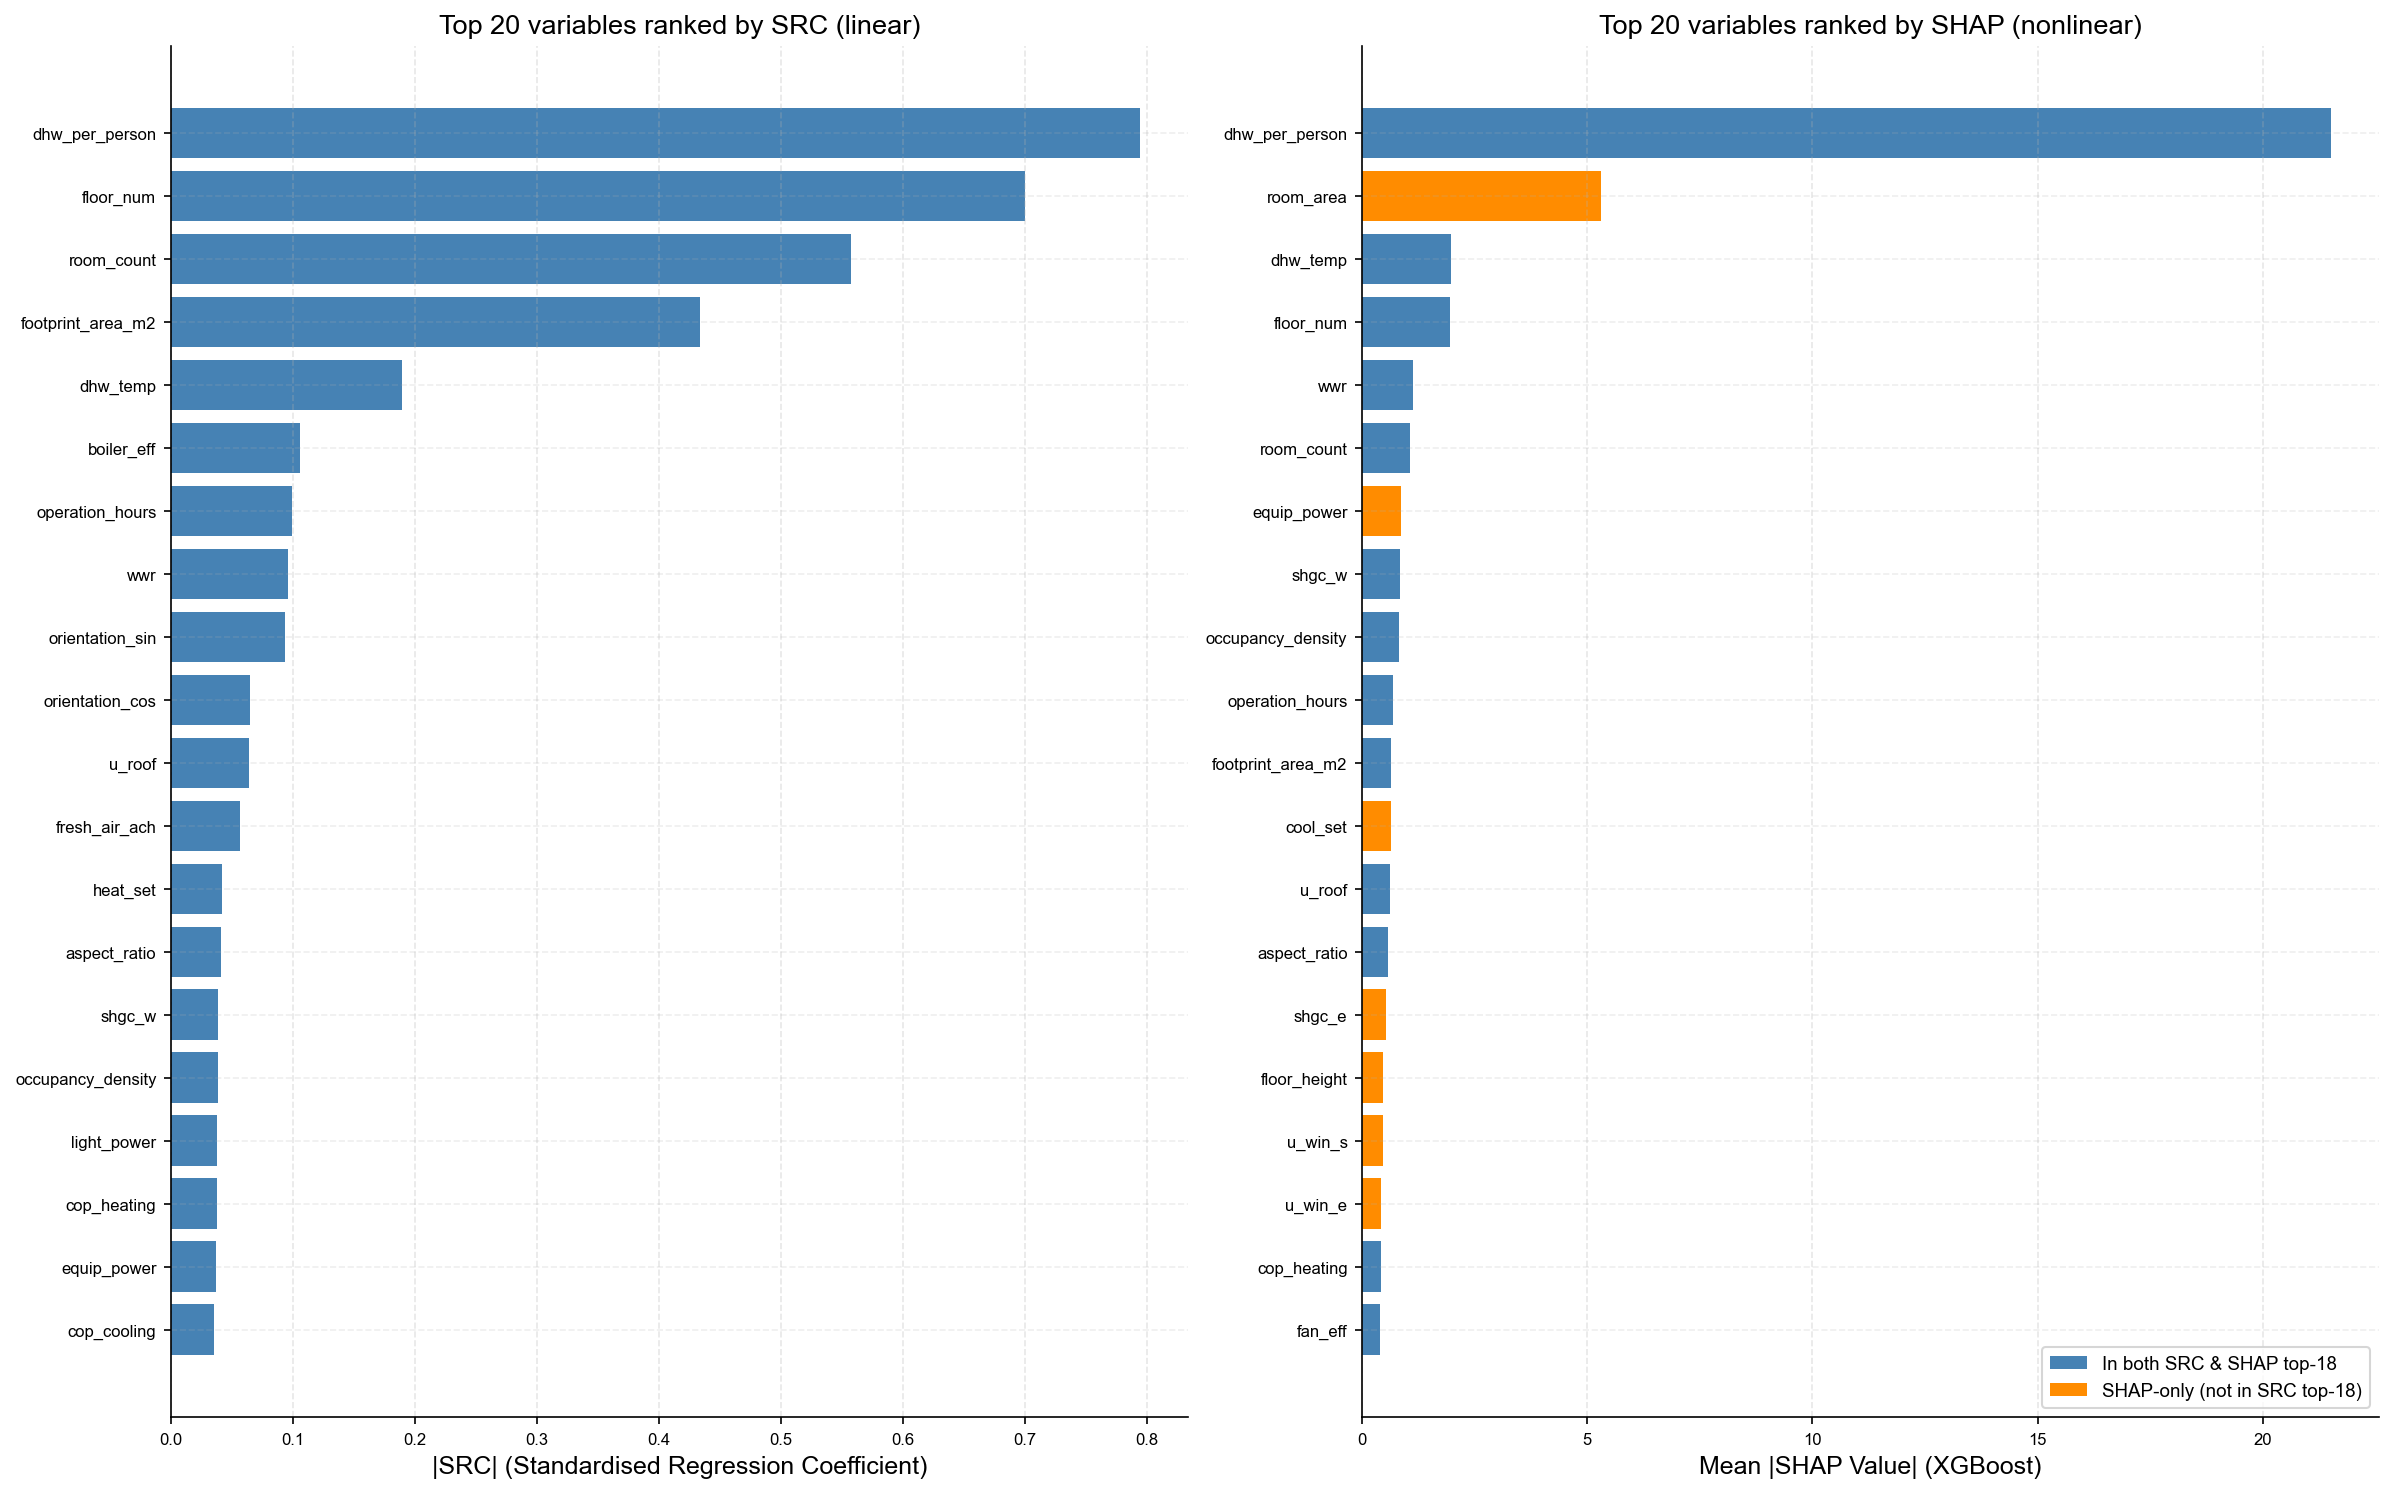

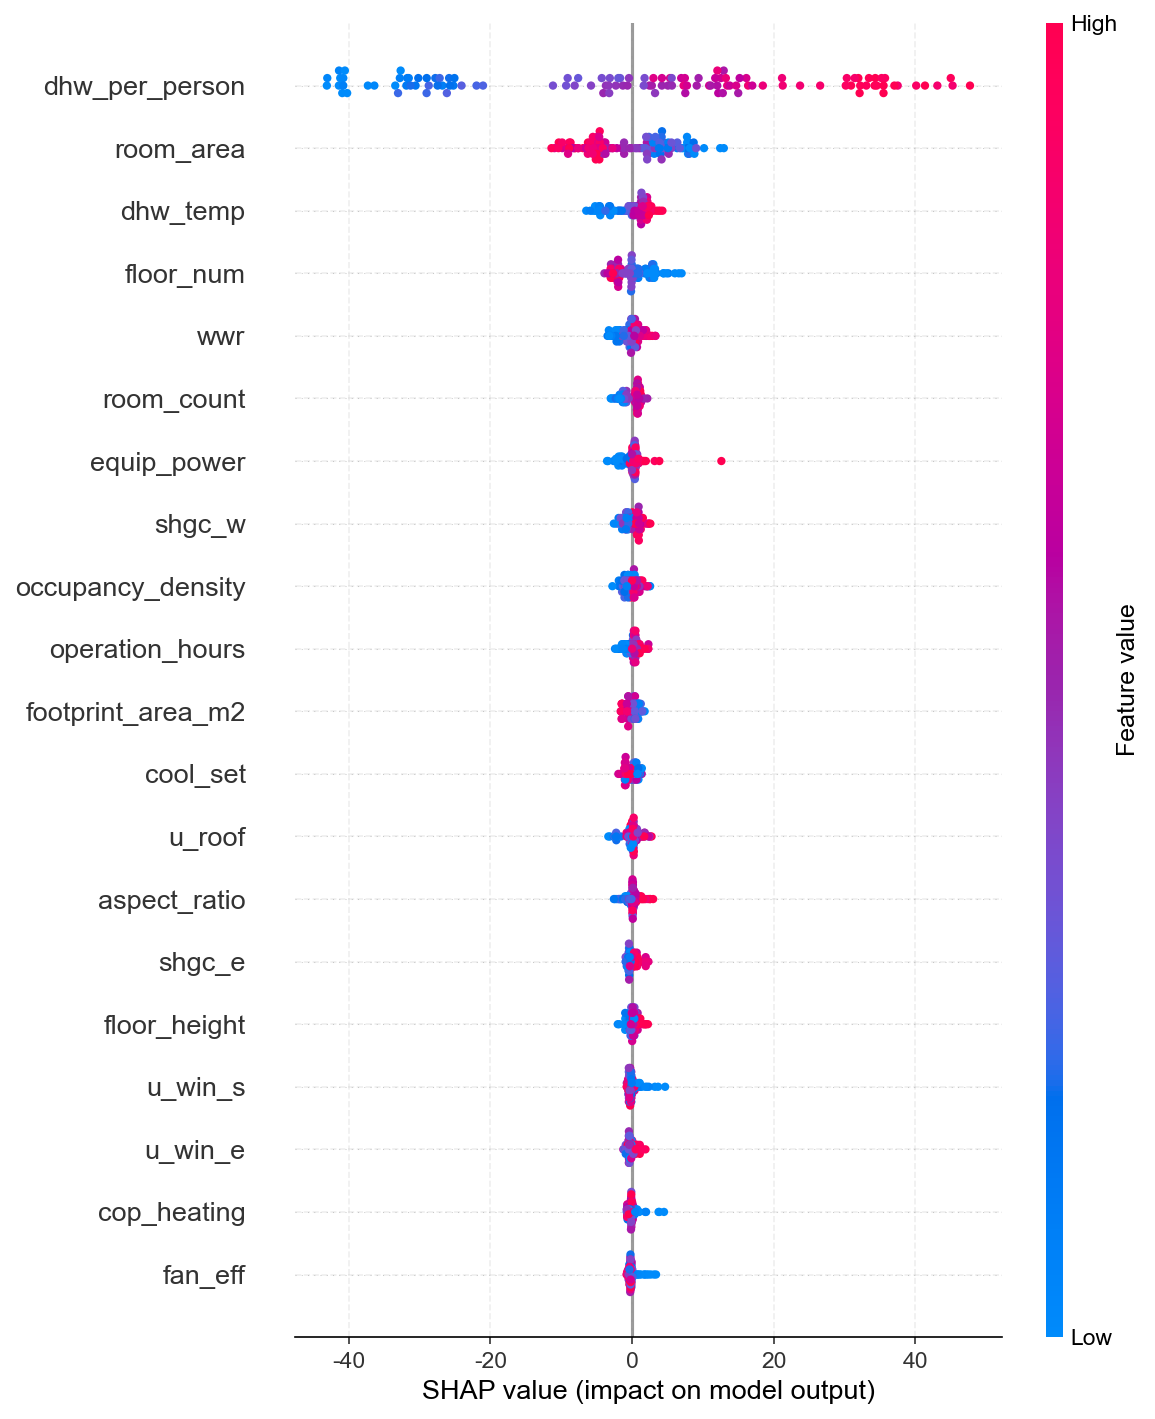


SRC-SHAP comparison saved.


In [7]:
# ============================================================
# [IMPROVEMENT P0-4 & P1-7] SHAP-Based Sensitivity Analysis
#
# Supplement SRC (linear) with SHAP values from XGBoost to:
# 1. Address the SRC-linearity limitation (Reviewer 1 Major 3)
# 2. Validate the 18-variable cutoff using a nonlinear method
# 3. Detect interaction effects invisible to SRC
# ============================================================

import shap
from xgboost import XGBRegressor

# Train XGBoost on all 39 features to get SHAP values
xgb = XGBRegressor(
    n_estimators=(200 if FAST_MODE else 500), max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)
xgb.fit(X, y)

# Compute SHAP values
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X)

# SHAP feature importance (mean |SHAP|)
shap_importance = pd.DataFrame({
    'feature': X.columns,
    'shap_abs_mean': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_abs_mean', ascending=False).reset_index(drop=True)

# Merge with SRC results for comparison
compare_df = src_df[['feature', 'abs_SRC', 'SRC']].merge(
    shap_importance, on='feature', how='left'
)
compare_df['src_rank'] = compare_df['abs_SRC'].rank(ascending=False)
compare_df['shap_rank'] = compare_df['shap_abs_mean'].rank(ascending=False)
compare_df['rank_delta'] = compare_df['src_rank'] - compare_df['shap_rank']

print("=" * 50)
print("SRC vs SHAP VARIABLE RANKING COMPARISON")
print("=" * 50)
print(f"Spearman rank correlation: {compare_df['src_rank'].corr(compare_df['shap_rank'], method='spearman'):.4f}")
print(f"\nTop 10 variables by SRC:  {compare_df.nsmallest(10, 'src_rank')['feature'].tolist()}")
print(f"Top 10 variables by SHAP: {compare_df.nsmallest(10, 'shap_rank')['feature'].tolist()}")
print(f"\nVariables with largest rank shift (|delta| > 5):")
large_shift = compare_df[compare_df['rank_delta'].abs() > 5].sort_values('rank_delta', key=abs, ascending=False)
for _, row in large_shift.iterrows():
    direction = 'higher in SHAP' if row['rank_delta'] < 0 else 'higher in SRC'
    print(f"  {row['feature']}: SRC rank={int(row['src_rank'])}, SHAP rank={int(row['shap_rank'])} ({direction})")

# Check: Do all SRC top-18 appear in SHAP top-18?
src_top18 = set(compare_df.nsmallest(18, 'src_rank')['feature'])
shap_top18 = set(compare_df.nsmallest(18, 'shap_rank')['feature'])
overlap = src_top18 & shap_top18
only_src = src_top18 - shap_top18
only_shap = shap_top18 - src_top18
print(f"\nTop-18 overlap: {len(overlap)}/18 (Jaccard={len(overlap)/len(src_top18|shap_top18):.3f})")
if only_src:
    print(f"Only in SRC top-18: {only_src}")
if only_shap:
    print(f"Only in SHAP top-18: {only_shap}")

# Visualisation: Side-by-side SRC vs SHAP
fig, axes = plt.subplots(1, 2, figsize=(16, 10), dpi=150)

# Panel 1: SRC top 20
top20_src = compare_df.nsmallest(20, 'src_rank').sort_values('abs_SRC')
axes[0].barh(top20_src['feature'], top20_src['abs_SRC'], color='steelblue')
axes[0].set_xlabel('|SRC| (Standardised Regression Coefficient)', fontsize=12)
axes[0].set_title('Top 20 variables ranked by SRC (linear)', fontsize=13)
axes[0].grid(axis='x', alpha=0.3)

# Panel 2: SHAP top 20
top20_shap = compare_df.nsmallest(20, 'shap_rank').sort_values('shap_abs_mean')
bar_colors = ['darkorange' if f in only_shap else 'steelblue' for f in top20_shap['feature']]
axes[1].barh(top20_shap['feature'], top20_shap['shap_abs_mean'], color=bar_colors)
axes[1].set_xlabel('Mean |SHAP Value| (XGBoost)', fontsize=12)
axes[1].set_title('Top 20 variables ranked by SHAP (nonlinear)', fontsize=13)
axes[1].grid(axis='x', alpha=0.3)
# Highlight variables not in SRC top-18
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='In both SRC & SHAP top-18'),
                   Patch(facecolor='darkorange', label='SHAP-only (not in SRC top-18)')]
axes[1].legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
out_dir = PROJECT_ROOT / 'outputs_step2' / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / 'src_vs_shap_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# SHAP summary plot (beeswarm)
fig2, ax2 = plt.subplots(figsize=(10, 8), dpi=150)
shap.summary_plot(shap_values, X, show=False, max_display=20)
plt.tight_layout()
fig2.savefig(out_dir / 'shap_summary_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

# Save comparison table
compare_df.to_csv(PROJECT_ROOT / 'outputs_step2' / 'src_shap_ranking_comparison.csv', index=False)
print("\nSRC-SHAP comparison saved.")


<!-- CODEx Chinese cell explanation: start -->
### Cell 08 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 08 — Computational step 08

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

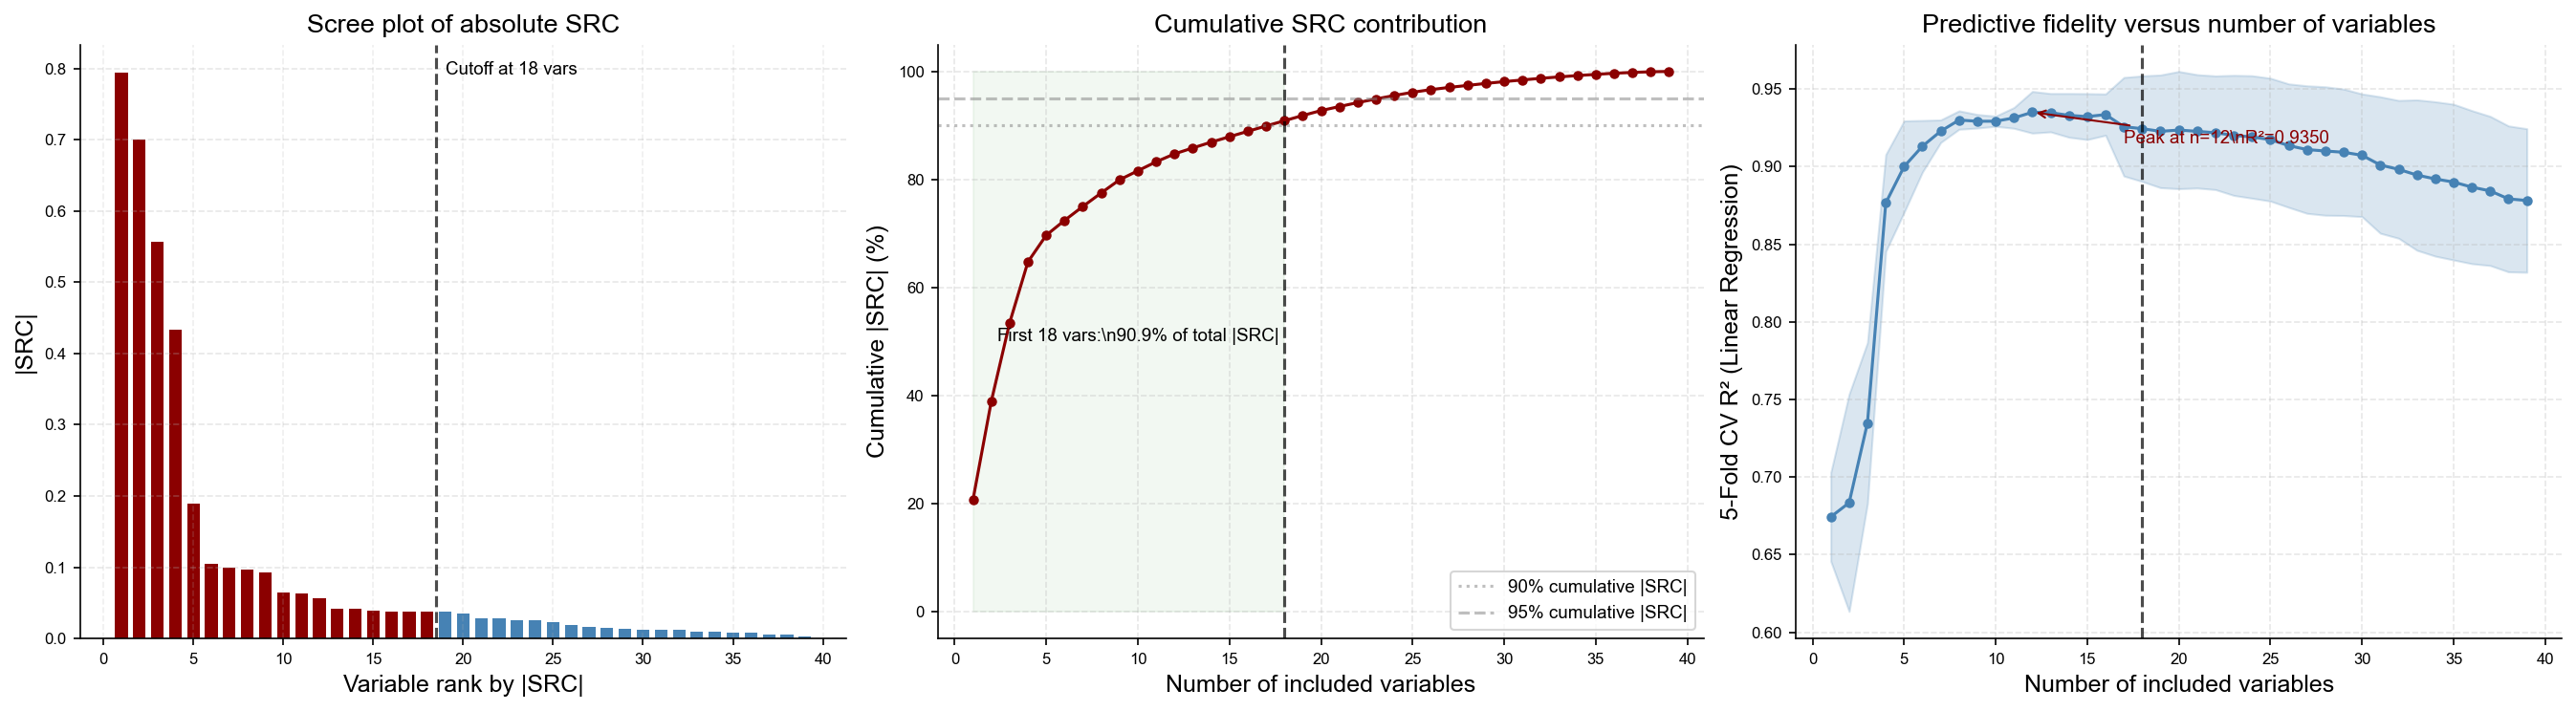


VARIABLE SELECTION ANALYSIS
Cumulative |SRC| at n=10: 81.6%
Cumulative |SRC| at n=18: 90.9%
Cumulative |SRC| at n=25: 96.1%
CV R² with 18 vars: 0.9244
Max CV R² (0.9350) at n=12


In [8]:
# ============================================================
# [IMPROVEMENT P1-7] Variable Selection Cutoff Analysis
#
# Analyse the natural breakpoints in SRC distribution to justify
# the 18-variable cutoff rather than an arbitrary threshold.
# ============================================================

# Compute cumulative SRC contribution and incremental drops
src_sorted = src_df.sort_values('abs_SRC', ascending=False).reset_index(drop=True)
src_sorted['cumulative_abs_src'] = src_sorted['abs_SRC'].cumsum()
src_sorted['cumulative_pct'] = (src_sorted['cumulative_abs_src'] /
                                 src_sorted['abs_SRC'].sum() * 100)
src_sorted['incremental_src'] = src_sorted['abs_SRC'].diff().abs()
src_sorted['pct_of_max'] = src_sorted['abs_SRC'] / src_sorted['abs_SRC'].max() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

# Panel 1: SRC scree plot
ax = axes[0]
colors = ['darkred' if i < 18 else 'steelblue' for i in range(len(src_sorted))]
ax.bar(range(1, len(src_sorted)+1), src_sorted['abs_SRC'], color=colors, width=0.7)
ax.axvline(18.5, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(19, ax.get_ylim()[1]*0.95, f'Cutoff at 18 vars', fontsize=9, ha='left')
ax.set_xlabel('Variable rank by |SRC|', fontsize=12)
ax.set_ylabel('|SRC|', fontsize=12)
ax.set_title('Scree plot of absolute SRC', fontsize=13)
ax.grid(axis='y', alpha=0.3)

# Panel 2: Cumulative contribution
ax = axes[1]
ax.plot(range(1, len(src_sorted)+1), src_sorted['cumulative_pct'], 'o-',
        color='darkred', markersize=4, linewidth=1.5)
ax.axhline(90, color='grey', linestyle=':', alpha=0.5, label='90% cumulative |SRC|')
ax.axhline(95, color='grey', linestyle='--', alpha=0.5, label='95% cumulative |SRC|')
ax.axvline(18, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.fill_between([1, 18], 0, 100, alpha=0.05, color='green')
ax.text(10, 50, f'First 18 vars:\\n{src_sorted.iloc[17]["cumulative_pct"]:.1f}% of total |SRC|',
        fontsize=9, ha='center')
ax.set_xlabel('Number of included variables', fontsize=12)
ax.set_ylabel('Cumulative |SRC| (%)', fontsize=12)
ax.set_title('Cumulative SRC contribution', fontsize=13)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel 3: CV R2 vs number of top variables
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

cv_r2_by_n = []
for n in range(1, len(X.columns)+1):
    top_n_features = src_sorted.head(n)['feature'].tolist()
    X_n = X[top_n_features]
    cv_scores = cross_val_score(LinearRegression(), X_n, y, cv=5, scoring='r2')
    cv_r2_by_n.append({'n_vars': n, 'cv_r2_mean': cv_scores.mean(), 'cv_r2_std': cv_scores.std()})

cv_df = pd.DataFrame(cv_r2_by_n)

ax = axes[2]
ax.fill_between(cv_df['n_vars'],
                cv_df['cv_r2_mean'] - cv_df['cv_r2_std'],
                cv_df['cv_r2_mean'] + cv_df['cv_r2_std'],
                alpha=0.2, color='steelblue')
ax.plot(cv_df['n_vars'], cv_df['cv_r2_mean'], 'o-', color='steelblue', markersize=4, linewidth=1.5)
ax.axvline(18, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Number of included variables', fontsize=12)
ax.set_ylabel('5-Fold CV R² (Linear Regression)', fontsize=12)
ax.set_title('Predictive fidelity versus number of variables', fontsize=13)
ax.grid(alpha=0.3)

# Annotate key points
best_n = cv_df.loc[cv_df['cv_r2_mean'].idxmax()]
ax.annotate(f'Peak at n={int(best_n["n_vars"])}\\nR²={best_n["cv_r2_mean"]:.4f}',
            xy=(best_n['n_vars'], best_n['cv_r2_mean']),
            xytext=(best_n['n_vars']+5, best_n['cv_r2_mean']-0.02),
            arrowprops=dict(arrowstyle='->', color='darkred'),
            fontsize=9, color='darkred')

plt.tight_layout()
fig.savefig(PROJECT_ROOT / 'outputs_step2' / 'figures' / 'variable_selection_analysis.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("\nVARIABLE SELECTION ANALYSIS")
print(f"Cumulative |SRC| at n=10: {src_sorted.iloc[9]['cumulative_pct']:.1f}%")
print(f"Cumulative |SRC| at n=18: {src_sorted.iloc[17]['cumulative_pct']:.1f}%")
print(f"Cumulative |SRC| at n=25: {src_sorted.iloc[24]['cumulative_pct']:.1f}%")
print(f"CV R² with 18 vars: {cv_df.loc[cv_df['n_vars']==18, 'cv_r2_mean'].values[0]:.4f}")
print(f"Max CV R² ({cv_df['cv_r2_mean'].max():.4f}) at n={int(best_n['n_vars'])}")

# Save
cv_df.to_csv(PROJECT_ROOT / 'outputs_step2' / 'cv_r2_by_variable_count.csv', index=False)


### Linear-assumption limitation of SRC and nonlinear supplementary validation

Standardised regression coefficients (SRCs) are interpretable first-order sensitivity indicators, but they rely on a linear approximation of the response surface. Because the simulated EUI response can contain nonlinear effects and interactions, this notebook supplements SRC with an XGBoost-SHAP analysis. The SRC-SHAP rank comparison, Spearman correlation, and top-18 overlap quantify whether the linear screening misses influential nonlinear variables.

The appropriate manuscript framing is therefore: SRC is used as a transparent first-stage screening tool, while SHAP provides a nonlinear robustness check rather than a replacement for a full variance-based global sensitivity analysis.

<!-- CODEx Chinese cell explanation: start -->
### Cell 09 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 09 — Computational step 09

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [9]:
# ---------- 5) Group-level summary ----------
group_rows = []
for gname, feats in feature_groups.items():
    sub = src_df[src_df["feature"].isin(feats)].copy()
    group_rows.append({
        "group": gname,
        "n_features": len(feats),
        "sum_abs_SRC": sub["abs_SRC"].sum(),
        "mean_abs_SRC": sub["abs_SRC"].mean(),
        "n_sign_stable": int(sub["sign_stable"].sum())
    })

group_df = pd.DataFrame(group_rows).sort_values("sum_abs_SRC", ascending=False)
group_df.to_csv(OUT_DIR / "src_group_summary.csv", index=False, encoding="utf-8-sig")
display(group_df)

,group,n_features,sum_abs_SRC,mean_abs_SRC,n_sign_stable
3,Operation_HVAC,13,1.499685,0.115360,6
1,Geometry_Form,6,1.351943,0.225324,2
2,Program_Zoning,3,0.572594,0.190865,1
0,Envelope,17,0.415590,0.024446,2


<!-- CODEx Chinese cell explanation: start -->
### Cell 10 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 10 — Computational step 10

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

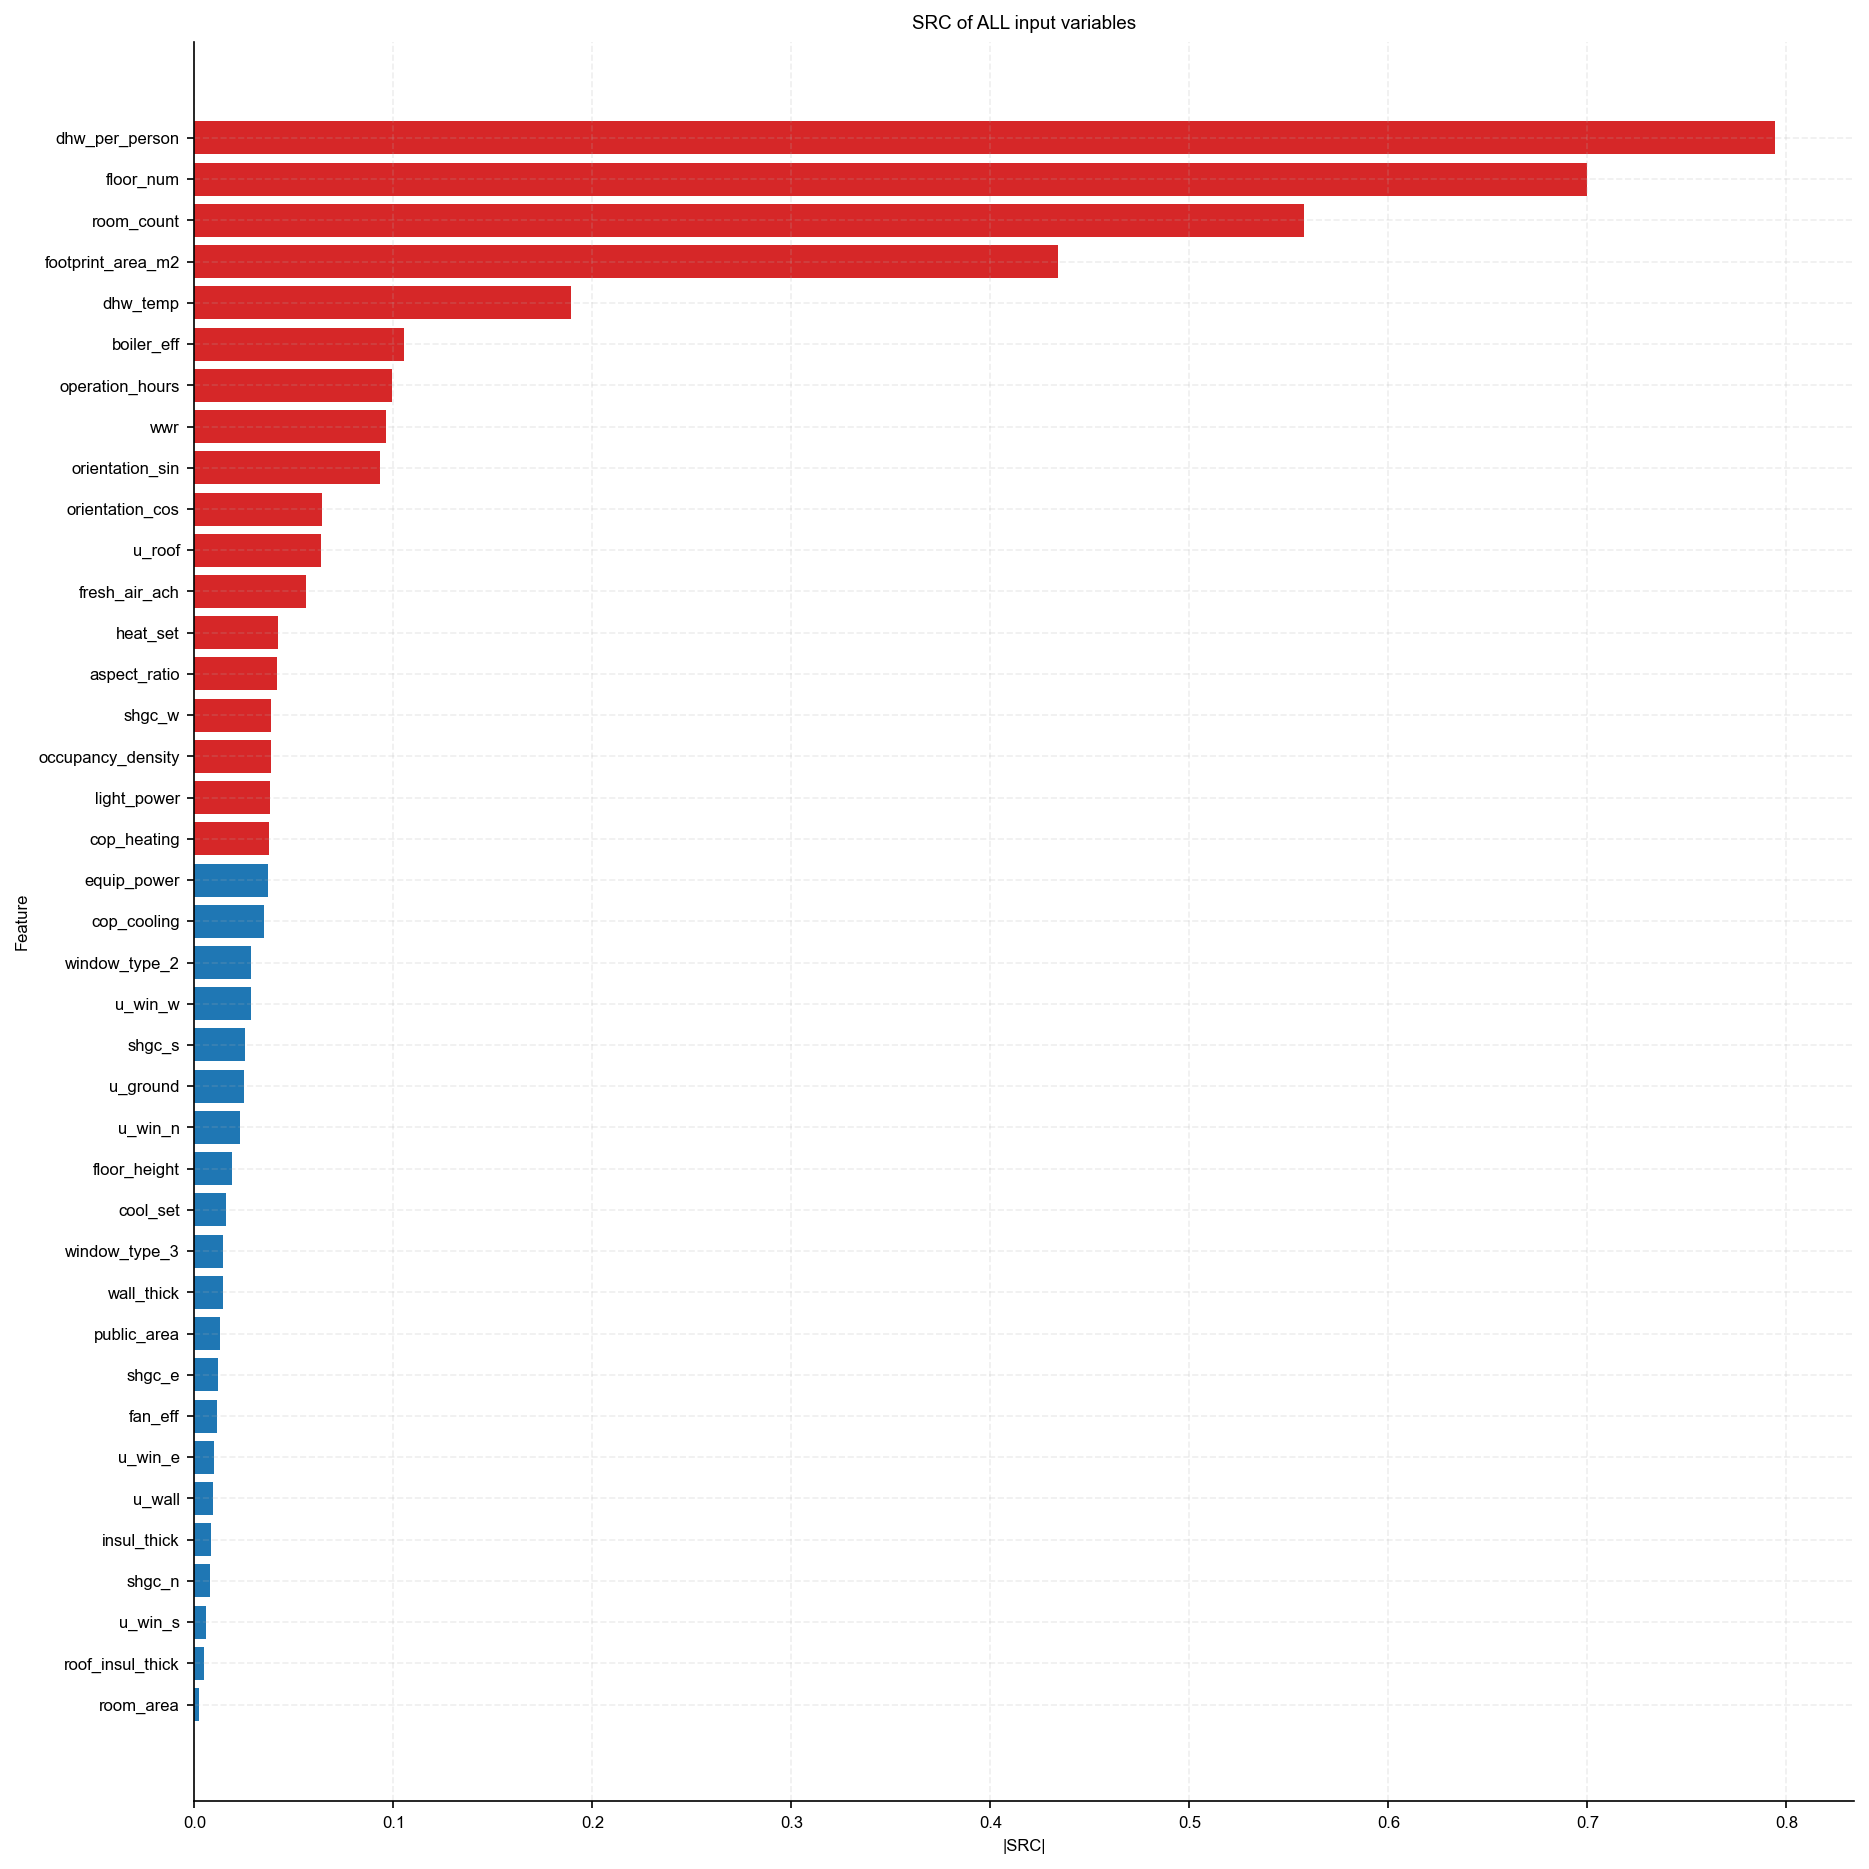

In [10]:
src_current = run_src_model(df, analysis_features, TARGET, seed=42, B=BOOTSTRAP_N)
src_current["rank_abs"] = src_current["abs_SRC"].rank(method="first", ascending=False)
src_current["is_top18"] = src_current["rank_abs"] <= 18

src_current["feature_full"] = src_current["feature"].map(feature_fullname_map)

src_current.to_csv(OUT_DIR / "src_current_all_inputs.csv", index=False, encoding="utf-8-sig")

plot_df = src_current.sort_values("abs_SRC", ascending=True).copy()
colors = ["tab:red" if x else "tab:blue" for x in plot_df["is_top18"]]

fig, ax = plt.subplots(figsize=(12.5, 12.5))
ax.barh(plot_df["feature"], plot_df["abs_SRC"], color=colors)
ax.set_title("SRC of ALL input variables")
ax.set_xlabel("|SRC|")
ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig(FIG_DIR / "src_all_current_inputs_top18_marked.png", dpi=300, bbox_inches="tight")
plt.show()

<!-- CODEx Chinese cell explanation: start -->
### Cell 11 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 11 — Computational step 11

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

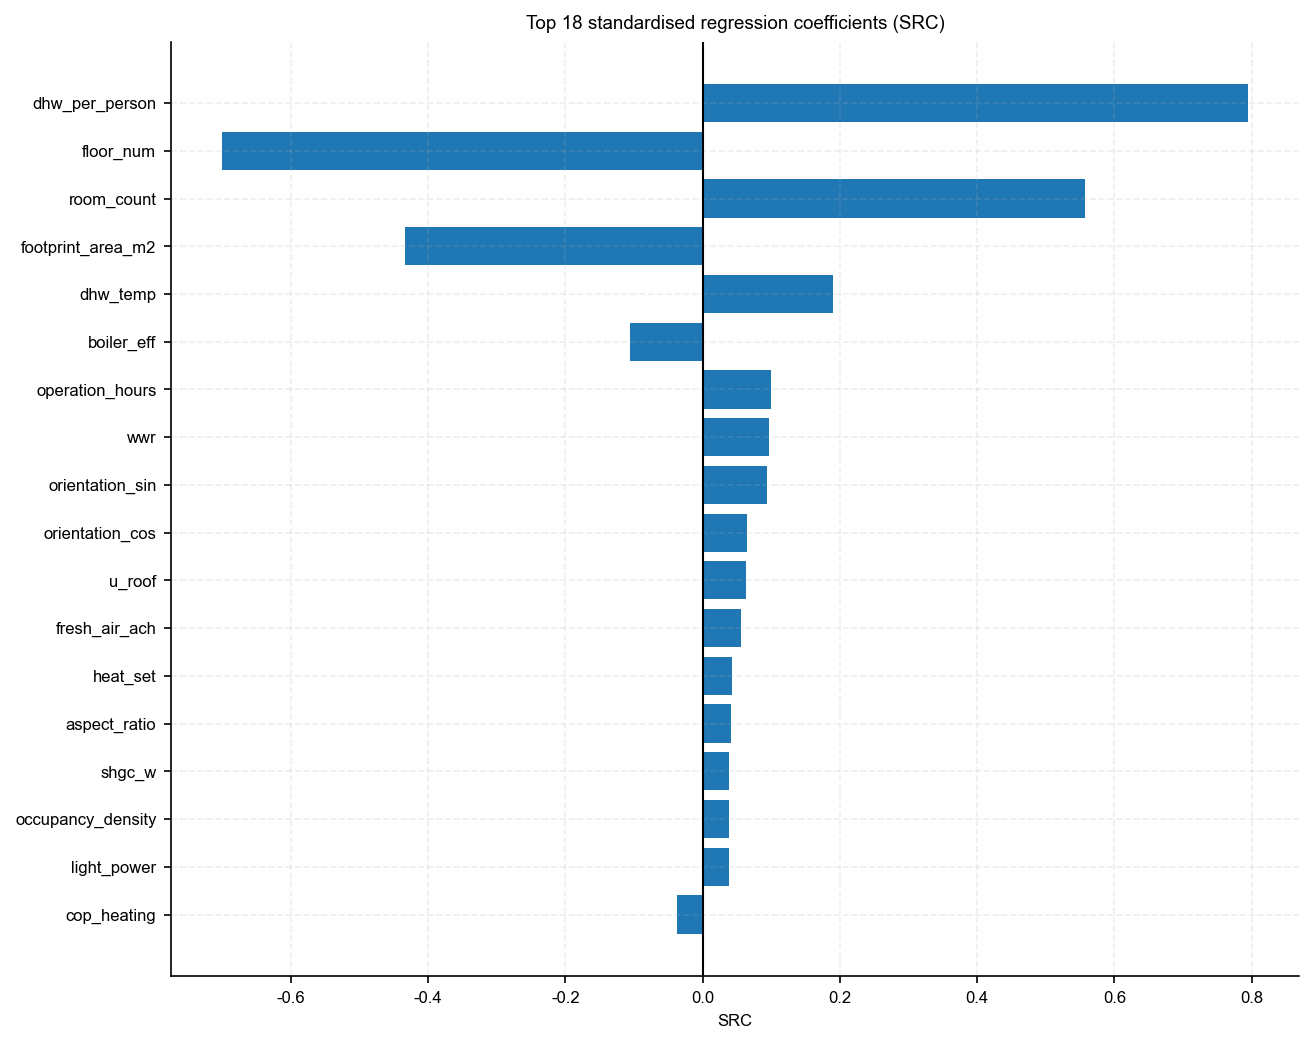

In [11]:
# ---------- 6) Top SRC ----------
plot_df = src_df.head(18).iloc[::-1].copy()

fig, ax = plt.subplots(figsize=(8.8, 7.0))
ax.barh(plot_df["feature"], plot_df["SRC"])
ax.axvline(0, color="black", linewidth=1.0)
ax.set_title("Top 18 standardised regression coefficients (SRC)")
ax.set_xlabel("SRC")
fig.tight_layout()
fig.savefig(FIG_DIR / "src_top18.png", bbox_inches="tight")
plt.show()

<!-- CODEx Chinese cell explanation: start -->
### Cell 12 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 12 — Computational step 12

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

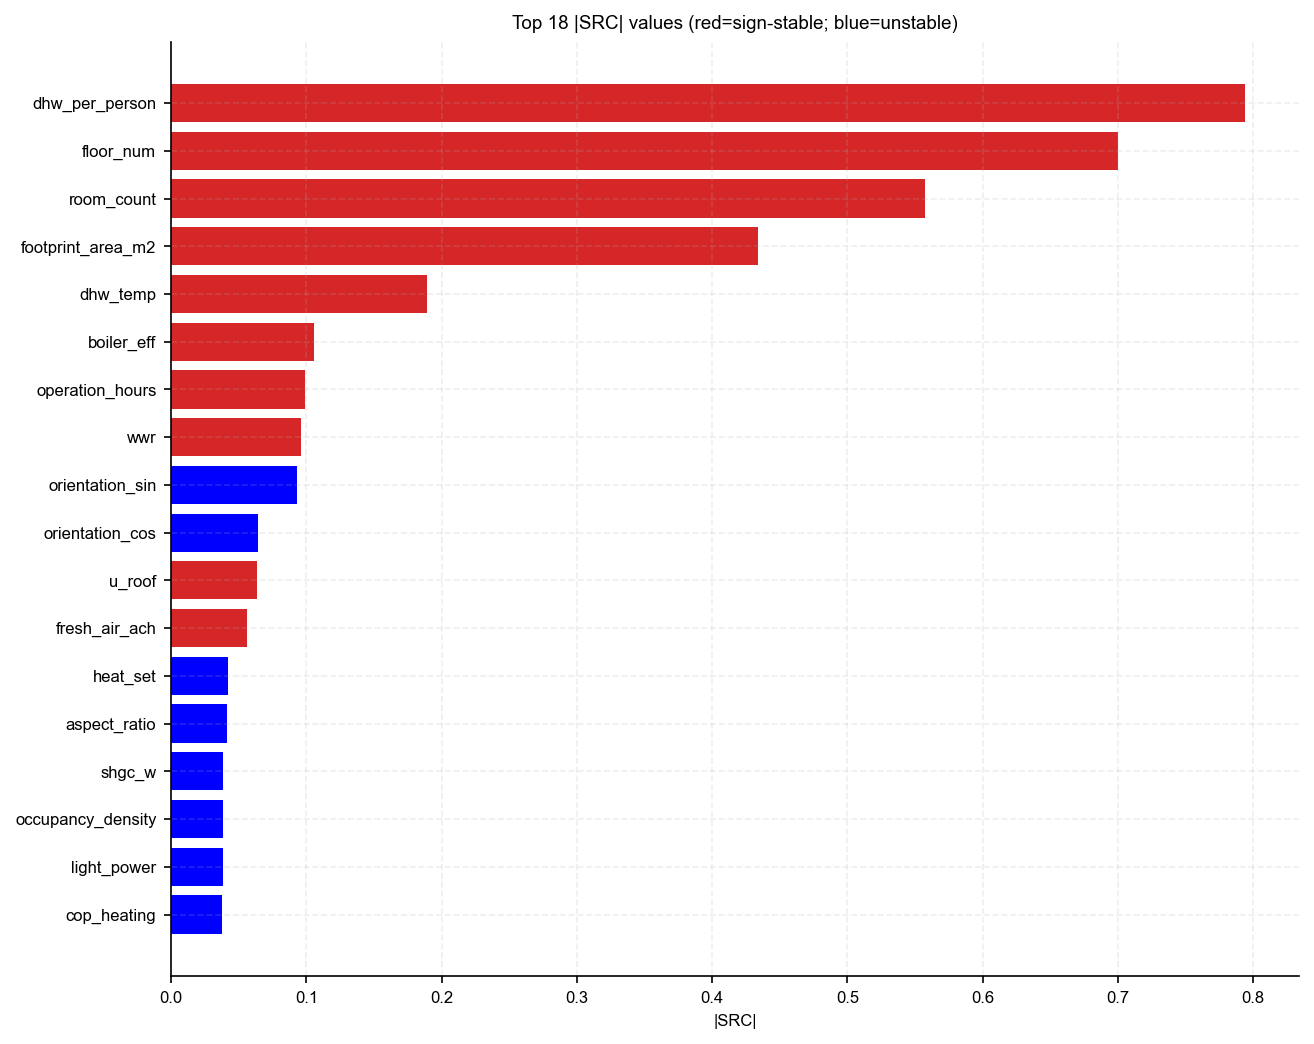

In [12]:
# ---------- 7) Stability markers ----------
sel = src_df.head(18).copy().sort_values("abs_SRC", ascending=True)

fig, ax = plt.subplots(figsize=(8.8, 7.0))
colors = ["tab:red" if s else "blue" for s in sel["sign_stable"]]
ax.barh(sel["feature"], sel["abs_SRC"], color=colors)
ax.set_title("Top 18 |SRC| values (red=sign-stable; blue=unstable)")
ax.set_xlabel("|SRC|")
fig.tight_layout()
fig.savefig(FIG_DIR / "src_abs_top18_stability.png", bbox_inches="tight")
plt.show()

<!-- CODEx Chinese cell explanation: start -->
### Cell 13 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 13 — Computational step 13

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

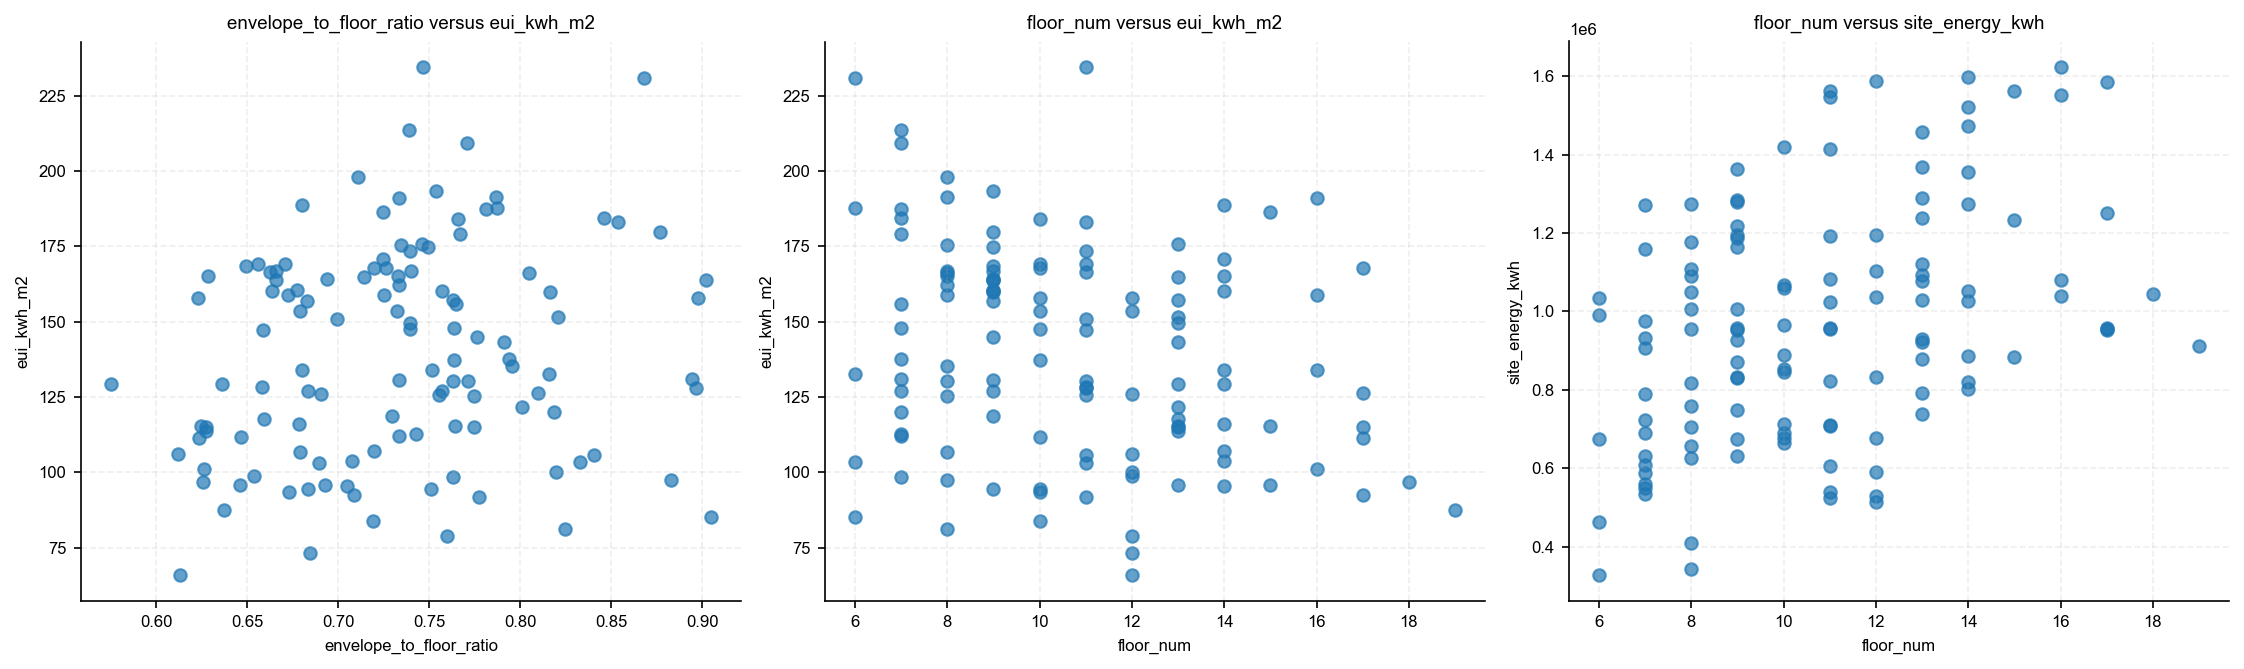

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(df["envelope_to_floor_ratio"], df["eui_kwh_m2"], alpha=0.7)
axes[0].set_xlabel("envelope_to_floor_ratio")
axes[0].set_ylabel("eui_kwh_m2")
axes[0].set_title("envelope_to_floor_ratio versus eui_kwh_m2")

axes[1].scatter(df["floor_num"], df["eui_kwh_m2"], alpha=0.7)
axes[1].set_xlabel("floor_num")
axes[1].set_ylabel("eui_kwh_m2")
axes[1].set_title("floor_num versus eui_kwh_m2")

axes[2].scatter(df["floor_num"], df["site_energy_kwh"], alpha=0.7)
axes[2].set_xlabel("floor_num")
axes[2].set_ylabel("site_energy_kwh")
axes[2].set_title("floor_num versus site_energy_kwh")

plt.tight_layout()
plt.show()

<!-- CODEx Chinese cell explanation: start -->
### Cell 14 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 14 — Computational step 14

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [14]:
src_eui = run_src_model(df, analysis_features, "eui_kwh_m2", seed=42, B=BOOTSTRAP_N)
src_site = run_src_model(df, analysis_features, "site_energy_kwh", seed=42, B=BOOTSTRAP_N)

compare_df = pd.DataFrame({
    "feature": analysis_features,
    "SRC_EUI": src_eui.set_index("feature").reindex(analysis_features)["SRC"].values,
    "SRC_site_energy": src_site.set_index("feature").reindex(analysis_features)["SRC"].values,
}).sort_values("SRC_EUI", key=np.abs, ascending=False)

display(compare_df.loc[
    compare_df["feature"].isin([
        "floor_num", "footprint_area_m2", "floor_height",
        "aspect_ratio", "public_area", "room_area", "room_count"
    ])
])
compare_df.to_csv(OUT_DIR / "src_target_comparison.csv", index=False, encoding="utf-8-sig")

,feature,SRC_EUI,SRC_site_energy
15,floor_num,-0.700039,0.333922
23,room_count,0.557486,0.395076
16,footprint_area_m2,-0.434042,0.200820
17,aspect_ratio,0.041270,-0.000969
18,floor_height,0.018913,-0.018011
21,public_area,0.012803,-0.028796
22,room_area,-0.002306,-0.013265


<!-- CODEx Chinese cell explanation: start -->
### Cell 15 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 15 — Computational step 15

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [15]:
physics_features = [
    'insul_thick', 'wwr', 'wall_thick',
    'u_win_n', 'u_win_s', 'u_win_e', 'u_win_w',
    'u_wall', 'u_roof', 'u_ground',
    'shgc_n', 'shgc_s', 'shgc_e', 'shgc_w',
    'roof_insul_thick',
    'envelope_to_floor_ratio',
    'public_area', 'room_area', 'room_count',
    'equip_power', 'dhw_per_person', 'occupancy_density', 'light_power',
    'cool_set', 'heat_set', 'dhw_temp',
    'cop_cooling', 'cop_heating', 'boiler_eff', 'fan_eff',
    'fresh_air_ach', 'operation_hours',
    'orientation_sin', 'orientation_cos',
    'window_type_2', 'window_type_3'
]

src_eui_physics = run_src_model(df, physics_features, "eui_kwh_m2", seed=42, B=BOOTSTRAP_N)
display(src_eui_physics.head(15))

src_eui_physics.to_csv(
    OUT_DIR / "src_physical_validation.csv",
    index=False,
    encoding="utf-8-sig"
)

,feature,SRC,abs_SRC,CI_low,CI_high,sign_stable
0,dhw_per_person,0.828447,0.828447,0.731733,0.931487,True
1,envelope_to_floor_ratio,0.401284,0.401284,0.284558,0.515220,True
2,room_count,0.316304,0.316304,0.208153,0.449954,True
3,dhw_temp,0.219110,0.219110,0.150533,0.309934,True
4,room_area,-0.117069,0.117069,-0.193720,-0.022521,True
5,wwr,0.090300,0.090300,0.031778,0.160645,True
6,u_win_e,0.089540,0.089540,0.014185,0.166954,True
7,light_power,0.083932,0.083932,0.013090,0.162692,True
8,fan_eff,-0.075096,0.075096,-0.135658,0.003143,False
9,orientation_cos,0.073684,0.073684,-0.088637,0.232630,False
